# Теория вероятностей и математическая статистика

*Алла Тамбовцева*

## Метод главных компонент: теория

### Общая логика

У нас есть массив с данными $X = (x_1, x_2, \dots, x_k)$, состоящий из $k$ вектор-столбцов $x_1, x_2, \dots, x_k$.
На его основе необходимо получить массив из $k$ главных компонент $\text{PC} = (\text{PC}_1, \text{PC}_2, \dots, \text{PC}_k)$, где произвольная $j$-ая главная компонента представляет собой линейную комбинацию исходных столбцов:

$$
\text{PC}_j = a_{1j}x_1 + a_{2j}x_2 + \dots + a_{kj}x_k.
$$

Веса ($a_{1j}, \dots, a_{kj}$) нужно подобрать таким образом, чтобы:

* обеспечить минимальную потерю информации – минимальную разницу между старым массивом $X$ и новым массивом $\text{PC}$;
* обеспечить максимальную вариативность (=информативность) главных компонент: $\text{PC}_1$ – самая информативная, $\text{PC}_2$ – менеее информативная, $\text{PC}_k$ – наименее информативная;
* гарантировать независимость (=ортогональность) главных компонент $\text{PC}_1$, $\dots$ $\text{PC}_k$.

Для чего это нужно? Для **снижения размерности**. Раз первые главные компоненты – самые информативные по построению, от последних главных компонент можно отказаться без особых потерь информации об исходных данных. Вместо того, чтобы работать с $k$ скоррелированными показателями, мы можем отобрать $p$ ($p$ сильно меньше $k$) нескоррелированных линейных комбинаций исходных показателей. Это может быть полезно в ряде задач, например:

* **Визуализация**. Невозможно отобразить на плоскости точки в пространстве выше двумерного; реализуем метод главных компонент, выбираем первые две компоненты, строим обычную диаграмму рассеивания.

* **Создание интегральных индексов**. Вместо вычисления среднего или взвешенного среднего по нескольких связанным друг с другом показателям реализуем на них метод главных компонент, выбираем первую (или несколько первых, если возможно содержательно интерпретировать) – получаем интегральный индекс, где большие веса имеют исходные показатели с большей дисперсией. Это полезно, поскольку большее разнообразие значений позволяет лучше дифференцировать наблюдения.

* **Избавление от сильной линейной зависимости**. Если во множественной линейной регрессии наблюдается мультиколлинеарность, сильно скоррелированные независимые переменные, из-за которых она возникает, можно «схлопнуть» в нескоррелированные главные компоненты и включить в модель.

### Реализация метода главных компонент: линейная алгебра

**Утверждение.** Для того, чтобы получить минимальную потерю информации об исходных данных и при этом сохранить максимальную дисперсию, нужно перейти к системе координат, в которой базисными векторами являются собственные векторы ковариационной матрицы длины 1.

Почему это так – вопрос нетривиальный, существуют разные способы доказательства. Можно почитать про отношение Рэлея и его связь с методом главных компонент. Еще можно пойти по другому пути и сравнивать метод главных компонент с методом наименьших квадратов: выбор положения оси, соответствующей первой главной компоненте напоминает выбор положения регрессионной прямой/гиперплоскости, так как и в том и в другом случае задачей является минимизация квадратов расстояний до прямой/гиперплоскости.

Алгоритм реализации метода главных компонент (как в Python):

1. Стандартизовать данные – центрировать и нормировать.
2. Получить ковариационную матрицу $\Sigma$ для стандартизированных данных.
3. Найти собственные значения ковариационной матрицы $\Sigma$.
4. Найти собственные векторы ковариационной матрицы $\Sigma$.
5. Найти собственные векторы ковариационной матрицы $\Sigma$, имеющие длину 1.
6. Записать матрицу из собственных векторов, найденных на предыдущем шаге (для определенности – вектор-столбцы). Тогда значения в каждом $j$-столбце такой матрицы – веса ($a_{1j}, \dots, a_{kj}$) из самого первого уравнения.

Формально этот алгоритм сводится к *спектральному разложению* ковариационной матрицы $\Sigma$ (не путать с сингулярным, в спектральном разложении задействованы собственные значения, а они с сингулярными в общем случае не совпадают):

$$
\Sigma = PSP^{-1} = SP^T, \text{ где: }
$$

* $S = \text{diag}(\lambda_1, \dots, \lambda_k)$ при $\lambda_1 > \lambda_2 > \dots > \lambda_k$, диагональная матрица из $k$ собственных значений ковариационной матрицы $\Sigma$, упорядоченных по убыванию.
* $P$ – матрица из $k$ собственных векторов ковариационной матрицы длины 1, записанных по столбцам, она же матрица перехода к новому базису из этих собственных векторов.

В данном случае $P^{-1} = P^T$, так как матрица $P$ является ортогональной матрицей, ее столбцы и строки задают ортонормированную систему векторов.

Геометрически, при реализации этого алгоритма мы поворачиваем исходные оси, задающиеся $k$ переменными, таким образом, чтобы перейти к более экономной системе координат, где тоже $k$ осей, но при этом разброс точек вдоль первой оси будет максимальным, по второй оси – чуть меньше, и так далее по убыванию. Оси в новой системе координат при этом ортогональны.

Содержательно, мы получаем:

1. Матрицу перехода $P$, которая позволяет найти координаты точек в новой системе координат, здесь это матрица поворота:

$$
\text{PC} = XP = (P^T X^T)^T.
$$

2. Матрицу $S$, которая позволяет оценить информативность каждой главной компоненты (от *Scale*). Собственное значение – это квадрат длины соответствующего собственного вектора до того, как мы приведем их к длине 1. Самому большому собственному значению соответствует самый длинный собственный вектор, а это и есть вектор, расположенный вдоль направления наибольшего разброса в данных, он же вектор, соответствующий первой главной компоненте.

### Реализация метода главных компонент: подключаем статистику

Во многих сферах, включая машинное обучение, значения из матрицы поворота выше (они же веса $a_{1j}, \dots, a_{kj}$ из самого первого уравнения) называют *нагрузками* или *факторными нагрузками*. Однако в факторном анализе такие веса обычно называют *стандартизованными факторными нагрузками*, поскольку они получаются уже после приведения собственных векторов к длине 1.

Чтобы не терять информацию об исходной длине вектора, в факторном анализе значения из матрицы поворота домножают на $\sqrt{\lambda_1}, \dots, \sqrt{\lambda_k}$, то есть на корни из соответствующих собственных значений, получая в итоге **матрицу факторных нагрузок**:

$$
A =
\begin{pmatrix}
a_{11} & a_{12} & \dots & a_{1l} & \dots & a_{1k} \\
a_{21} & a_{22} & \dots & a_{2l} & \dots & a_{2k} \\
\dots & \dots & \dots & \dots & \dots & \dots \\
a_{i1} & a_{i2} & \dots & a_{il} & \dots & a_{ik} \\
a_{j1} & a_{j2} & \dots & a_{jl} & \dots & a_{jk} \\
\dots & \dots & \dots & \dots & \dots & \dots \\
a_{k1} & a_{k2} & \dots & a_{kl} & \dots & a_{kk} \\
\end{pmatrix}
$$

Матрица квадратная, по строкам такой матрицы идут исходные переменные (номера 1, 2, $\dots$, $i$, $j$, $\dots$, $k$), по столбцам – главные компоненты (номера 1, 2, $\dots$, $l$, $\dots$, $k$).

Свойства матрицы:

1. $a_{il}^2$ – доля дисперсии $i$-той переменной, объясненной $l$-той главной компонентой.
2. $\sum\limits_{l=1}^{k}{a^2_{il}} = 1$, сумма квадратов нагрузок в строке $i$ равна 1 (для всех строк).
3. $\sum\limits_{i=1}^{k}{a^2_{il}} = \lambda_ l$, сумма квадратов нагрузок в столбце $l$ равна собственному значению, соответствующему $l$-той главной компоненте (для всех столбцов).
4. $\sum\limits_{l=1}^{k}a_{il} \cdot a_{jl} = R_{ij}$, скалярное произведение $i$-той и $j$-той строки матрицы равно коэффициенту корреляции между $i$-той и $j$-той переменной в исходных данных.

Благодаря такой матрице мы можем:

а) восстановить информацию о корреляционной матрице исходных данных, так как $AA^T = R$ (здесь $R$ – корреляционная матрица для исходных переменных, на которых реализовывали метод главных компонент), см. свойство 4;

б) найти долю дисперсии, которую каждая главная компонента объясняет в *каждом* исходном показателе, см. свойство 1;

в) найти долю дисперсии исходных данных (*общую*, все показатели сразу), которую объясняет каждая главная компонента, см. свойство 3.

Результат пункта в) часто называют **информативностью** $l$-той главной компоненты:

$$
I_{l} = \frac{\lambda_l}{\sum_{l=1}^{k}{\lambda_i}} = \frac{\lambda_l}{k}.
$$

Сколько главных компонент выбрать – рассмотрим способы ответа на этот вопрос в практической части.

## Метод главных компонент: практика

### Подготовка к работе

Импортируем необходимые для работы библиотеки и функции:

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Загрузим данные по оценкам слушателей курса ТВиМС (политологи, 1 курс), файл доступен по [ссылке](https://disk.yandex.ru/i/Xtm386zwjOazxQ):

In [2]:
df = pd.read_excel("ТВиМС 2025.xlsx")
df.head()

,КР,ДЗ1,ДЗ2,ДЗ3,Т1,Т2,Т3,Т4,Т5,Т6,Т7,Т8,Семинары
0,6,7,10,10,9,7,10,4,10,5,10,10,7
1,4,8,10,9,8,5,8,10,10,10,0,10,1
2,9,10,10,10,10,0,8,9,9,10,7,4,3
3,4,7,9,10,7,4,10,10,10,10,10,9,10
4,8,9,10,8,10,9,6,10,6,10,10,8,8


Переменные в файле:

* `КР` – оценка за контрольную работу;
* `ДЗ1`-`ДЗ3` – оценки за домашние задания;
* `Т1`-`Т8` – оценки за тесты;
* `Семинары` – оценка за семинарскую активность.

**NB.** Строго говоря, оценки в 10-балльной шкале – данные порядковые, а метод главных компонент – для количественных, но принебрежем этим фактом, все-таки категорий здесь 10, а это немало. Если интересует снижение размерности в случае неколичественных данных, рекомендую почитать про [многомерное шкалирование](https://en.wikipedia.org/wiki/Multidimensional_scaling#:~:text=Multidimensional%20scaling%20(MDS)%20is%20a,into%20an%20abstract%20Cartesian%20space.). Идея там схожая, только если в методе главных компонент нас интересуют связи между переменными (разложение ковариационной матрицы), в многомерном шкалировании нас интересует близость наблюдений (разложение матрицы близостей или матрицы расстояний). А подобрать подходящее для разных типов данных расстояние, как мы уже убедились в кластерном анализе, несложно.

Вернемся к данным. Допустим, мы хотим на основе оценок за разные формы контроля получить агрегированные показатели успеваемости по этому курсу. Так как контрольная работа проводилась по материалам 3 модуля, давайте оценки за тесты тоже разобьем на части – посчитаем среднюю оценку за тесты в 3 и 4 модулях:

In [3]:
# среднее по строкам (axis = 1)

df["Тесты1"] = df[["Т1", "Т2", "Т3", "Т4", "Т5"]].mean(axis = 1)
df["Тесты2"] = df[["Т6", "Т7", "Т8"]].mean(axis = 1)
df.head()

,КР,ДЗ1,ДЗ2,ДЗ3,Т1,Т2,Т3,Т4,Т5,Т6,Т7,Т8,Семинары,Тесты1,Тесты2
0,6,7,10,10,9,7,10,4,10,5,10,10,7,8.0,8.333333
1,4,8,10,9,8,5,8,10,10,10,0,10,1,8.2,6.666667
2,9,10,10,10,10,0,8,9,9,10,7,4,3,7.2,7.000000
3,4,7,9,10,7,4,10,10,10,10,10,9,10,8.2,9.666667
4,8,9,10,8,10,9,6,10,6,10,10,8,8,8.2,9.333333


Выберем ключевые столбцы и посмотрим на корреляции в исходных данных:

In [4]:
data = df[['КР', 'ДЗ1', 'ДЗ2', 'ДЗ3', 'Семинары', 'Тесты1', 'Тесты2']]
data.corr()

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2
КР,1.000000,0.611359,0.332205,0.549093,0.477515,0.588569,0.330548
ДЗ1,0.611359,1.000000,0.524211,0.703248,0.343521,0.649323,0.457596
ДЗ2,0.332205,0.524211,1.000000,0.500834,0.200004,0.398490,0.348280
ДЗ3,0.549093,0.703248,0.500834,1.000000,0.408691,0.621782,0.510651
Семинары,0.477515,0.343521,0.200004,0.408691,1.000000,0.425638,0.472389
Тесты1,0.588569,0.649323,0.398490,0.621782,0.425638,1.000000,0.600185
Тесты2,0.330548,0.457596,0.348280,0.510651,0.472389,0.600185,1.000000


In [5]:
data.describe()

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,5.021053,7.578947,8.684211,8.431579,3.915789,6.381053,6.235088
std,2.701375,2.549839,2.899975,2.819584,3.456918,2.655235,3.167459
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,7.000000,9.000000,8.000000,1.000000,4.800000,4.000000
50%,5.000000,8.000000,10.000000,10.000000,3.000000,7.000000,7.333333
75%,7.000000,9.000000,10.000000,10.000000,6.500000,8.200000,8.833333
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


Супер-высоких значений коэффициентов не наблюдается, но значения, которые мы видим здесь, вполне логичны:

* относительно сильно скоррелированы оценки за ДЗ№1 и контрольную работу, объяснимо, так как это домашнее задание было ключевым и самым содержательным в 3 модуле; то же относится и к тестам третьего модуля (`Тесты1`);

* оценки за тесты третьего и четвертого модуля связаны, коэффициент корреляции 0.6, тоже ожидаемо, однако связь не очень высокая – тесты в четвертом модуле, в целом, многие студенты стали писать более серьезно, видя не очень вдохновляющие результаты контрольной работы, но сами темы усложнились.

Стандартизуем данные с помощью знакомого класса `StandardScaler()`, центрируем и нормируем данные:

In [6]:
X = StandardScaler().fit_transform(data)
data_scaled = pd.DataFrame(X, columns = data.columns)
data_scaled.head()

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2
0,0.364311,-0.228257,0.456131,0.559211,0.896918,0.612954,0.665952
1,-0.379980,0.166005,0.456131,0.202667,-0.847940,0.688676,0.136977
2,1.480748,0.954529,0.456131,0.559211,-0.266320,0.310064,0.242772
3,-0.379980,-0.228257,0.109472,0.559211,1.769347,0.688676,1.089133
4,1.108603,0.560267,0.456131,-0.153877,1.187728,0.688676,0.983338


Убедимся, что дисперсия переменных после стандартизации равна 1, а среднее – 0:

In [7]:
# примерно, Python накапливает ошибку при работе с типом float

data_scaled.describe().round(2)

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2
count,95.00,95.00,95.00,95.00,95.00,95.00,95.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-1.87,-2.99,-3.01,-3.01,-1.14,-2.42,-1.98
25%,-0.75,-0.23,0.11,-0.15,-0.85,-0.60,-0.71
50%,-0.01,0.17,0.46,0.56,-0.27,0.23,0.35
75%,0.74,0.56,0.46,0.56,0.75,0.69,0.82
max,1.85,0.95,0.46,0.56,1.77,1.37,1.19


### Реализация алгоритма

Приступим к реализации метода главных компонент. Так как функции для реализации предполагают работу с массивами без подписей строк и столбцов, для наглядности будем преобразовывать результаты в датафреймы и добавлять подписи сами. Создадим список названий главных компонент:

In [8]:
# число компонент = число столбцов в исходных данных

p = data_scaled.shape[1]
pca_names = ["PC" + str(i) for i in range(1, p + 1)]
print(pca_names)

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']


Запускаем алгоритм:
    
* `PCA()` резервирует место для результатов и фиксирует параметры – число компонент в данном случае;
* `.fit_transform()` реализует метод главных компонент и возвращает координаты наблюдений в новых осях – значения главных компонент для всех наблюдений в данных.

In [9]:
# переделываем результат fit_transform() из массива
# в датафрейм для наглядности

pca = PCA(n_components = p)
pca_res = pd.DataFrame(pca.fit_transform(data_scaled),
                       columns = pca_names)
print(pca_res.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7
0  1.195023  0.551075  0.387105  0.371470 -0.102893  0.200621 -0.508746
1  0.229391 -0.880323  0.453058 -0.623481 -0.229241  0.377128 -0.129444
2  1.478203 -0.552319 -0.858799 -0.241342 -0.263177 -0.701513 -0.056702
3  1.258709  1.377982  1.057130  0.513736  0.322013  0.572182 -0.128636
4  1.745473  0.822709 -0.015523  0.387115 -0.756708 -0.294812  0.305630


Здесь  1.195 – это значение первой главной компоненты (условно – первого индекса успеваемости) для первого студента, 0.552 – значение второй главной компоненты (условно – второго индекса успеваемости) для третьего студента, и так далее.

**NB.** Если у вас получились другие знаки, у вас более старая версия `sklearn`. Это некритично, просто если здесь первую главную компоненту мы будем воспринимать как «индекс успеваемости», у вас будет «индекс неуспеваемости», к которому можно добавить минус и получить то же, что в выдаче выше. В рамках метода главных компонент нет единственного решения, поскольку для перехода из одной системы координат в другую, исходные оси можно повернуть как против, так и по часовой стрелке. Вспомним вид матрицы поворота для двумерного случая:

$$
\begin{pmatrix}
\cos\alpha & \mp \sin\alpha\\
\pm \sin\alpha & \cos\alpha
\end{pmatrix}
$$

Верхние знаки перед синусом отвечают за поворот против часовой стрелки, нижние – по часовой стрелке. Так, можно повернуть оси на угол $\alpha$ против часовой стрелки или на угол $(360^\circ-\alpha)$ по часовой стрелке, разницы никакой не будет. Различия будут выражаться только в знаках синуса.

Посмотрим на полученные результаты с позиции линейной алгебры. По итогам метода главных компонент мы должны получить диагональную матрицу из собственных значений и квадратную марицу поворота. Собственные значения – элементы главной диагонали такой матрицы – хранятся в атрибуте `explained_variance_`, так как они соответствуют дисперсии исходных данных, объясненной каждой главной компонентой:

In [10]:
pca_var = pca.explained_variance_
print(pca_var.round(2))

[3.96 0.9  0.7  0.56 0.39 0.28 0.27]


Итак, $S = \text{diag}(3.96, 0.9,  0.7,  0.56, 0.39, 0.28, 0.27)$. Посмотрим на матрицу перехода, матрицу поворота $P$. В Python значения единичных собственных векторов обычно записываются в массив по строкам, для более привычного вида переведем все в датафрейм и транспонируем:

In [11]:
print(pca.components_)

[[ 0.37925589  0.4229154   0.31250096  0.42200048  0.31107028  0.42126815
   0.35683989]
 [ 0.11192428 -0.2707602  -0.60543305 -0.16436132  0.66521859  0.0630143
   0.27223424]
 [-0.64710829 -0.19775312  0.27808653 -0.02599945 -0.00622479  0.02891555
   0.68063325]
 [ 0.03622306 -0.17376477  0.60054431 -0.09072792  0.58778841 -0.44292694
  -0.24068484]
 [-0.36944114  0.21309985 -0.29532308  0.73055148  0.14861526 -0.40013889
  -0.12240458]
 [-0.45909641 -0.09824083  0.05569801  0.05084136  0.24648189  0.67147509
  -0.51211326]
 [-0.27626148  0.78960001 -0.08654711 -0.49970302  0.17984922 -0.10272312
  -0.01096013]]


In [12]:
# переводим в датафрейм, транспонируем
# добавляем названия строкам и столбцам

rotation = pd.DataFrame(pca.components_).T
rotation.columns = pca_names
rotation.index = data.columns
rotation

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
КР,0.379256,0.111924,-0.647108,0.036223,-0.369441,-0.459096,-0.276261
ДЗ1,0.422915,-0.270760,-0.197753,-0.173765,0.213100,-0.098241,0.789600
ДЗ2,0.312501,-0.605433,0.278087,0.600544,-0.295323,0.055698,-0.086547
ДЗ3,0.422000,-0.164361,-0.025999,-0.090728,0.730551,0.050841,-0.499703
Семинары,0.311070,0.665219,-0.006225,0.587788,0.148615,0.246482,0.179849
Тесты1,0.421268,0.063014,0.028916,-0.442927,-0.400139,0.671475,-0.102723
Тесты2,0.356840,0.272234,0.680633,-0.240685,-0.122405,-0.512113,-0.010960


Итак, матрицу $P$ мы тоже получили. В ней хранятся *стандартизованные факторные нагрузки*. Проверим, что эта матрица поворота – полноценная ортонормированная матрица:

In [13]:
# суммы по строкам и столбцам = 1
# столбцы ортогональны, скалярное произведение 0

print((rotation ** 2).sum(axis = 0))
print((rotation ** 2).sum(axis = 1))
print("PC1 . PC2:", round(np.dot(rotation["PC1"], rotation["PC2"]), 4))

PC1    1.0
PC2    1.0
PC3    1.0
PC4    1.0
PC5    1.0
PC6    1.0
PC7    1.0
dtype: float64
КР          1.0
ДЗ1         1.0
ДЗ2         1.0
ДЗ3         1.0
Семинары    1.0
Тесты1      1.0
Тесты2      1.0
dtype: float64
PC1 . PC2: 0.0


Проинтерпретируем полученные результаты. Первая главная компонента – общий индекс успеваемости по курсу, в него исходные показатели входят с примерно одинаковыми весами. Вторая главная компонента поинтереснее. В нее с положительными весами входят аудиторные формы контроля, плюс, оценка за семинары имеет самый большой вес, а вот домашние задания входят с отрицательными весами. Значит, вторая главная компонента – это индекс аудиторной активности.

Напоследок убедимся, что значения главных компонент в `pca_res` выше получаются перемножением матрицы поворота и массива с исходными данными:

In [14]:
# сравниваем с произведением матриц XP
# или (P^T * X^T )^T, если очень хочется, чтобы матрица перехода была первой

print(pca_res.head())
print(pd.DataFrame(np.dot(data_scaled, rotation)).head())
print(pd.DataFrame(np.dot(rotation.T, data_scaled.T).T).head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7
0  1.195023  0.551075  0.387105  0.371470 -0.102893  0.200621 -0.508746
1  0.229391 -0.880323  0.453058 -0.623481 -0.229241  0.377128 -0.129444
2  1.478203 -0.552319 -0.858799 -0.241342 -0.263177 -0.701513 -0.056702
3  1.258709  1.377982  1.057130  0.513736  0.322013  0.572182 -0.128636
4  1.745473  0.822709 -0.015523  0.387115 -0.756708 -0.294812  0.305630
          0         1         2         3         4         5         6
0  1.195023  0.551075  0.387105  0.371470 -0.102893  0.200621 -0.508746
1  0.229391 -0.880323  0.453058 -0.623481 -0.229241  0.377128 -0.129444
2  1.478203 -0.552319 -0.858799 -0.241342 -0.263177 -0.701513 -0.056702
3  1.258709  1.377982  1.057130  0.513736  0.322013  0.572182 -0.128636
4  1.745473  0.822709 -0.015523  0.387115 -0.756708 -0.294812  0.305630
          0         1         2         3         4         5         6
0  1.195023  0.551075  0.387105  0.371470 -0.102893  0.200621 -0

### Матрица факторных нагрузок

Теперь перейдем к обычной **матрице факторных нагрузок**. Домножим матрицу поворота выше на квадратные корни из собственных значений:

In [15]:
A = rotation * np.sqrt(pca_var)
A

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
КР,0.755150,0.106218,-0.543017,0.027128,-0.229553,-0.244751,-0.144580
ДЗ1,0.842082,-0.256956,-0.165943,-0.130135,0.132410,-0.052374,0.413233
ДЗ2,0.622232,-0.574566,0.233355,0.449755,-0.183499,0.029693,-0.045294
ДЗ3,0.840261,-0.155982,-0.021817,-0.067947,0.453929,0.027104,-0.261517
Семинары,0.619383,0.631304,-0.005223,0.440202,0.092342,0.131403,0.094123
Тесты1,0.838802,0.059802,0.024264,-0.331713,-0.248627,0.357973,-0.053760
Тесты2,0.710517,0.258355,0.571149,-0.180252,-0.076056,-0.273015,-0.005736


Проверим сформулированные в теоретической части свойства:

In [16]:
# суммы квадратов нагрузок по строкам = 1
# тут примерно 1, далее поймем, в чем причина расхождений

print((A ** 2).sum(axis = 1))

КР          1.010638
ДЗ1         1.010638
ДЗ2         1.010638
ДЗ3         1.010638
Семинары    1.010638
Тесты1      1.010638
Тесты2      1.010638
dtype: float64


In [17]:
# суммы по столбцам квадратов нагрузок = собственные значения
# из explained_variance

print((A ** 2).sum(axis = 0))
print("Для сравнения:", pca_var)

PC1    3.964624
PC2    0.900634
PC3    0.704162
PC4    0.560869
PC5    0.386077
PC6    0.284211
PC7    0.273890
dtype: float64
Для сравнения: [3.96462448 0.90063353 0.70416226 0.56086934 0.38607724 0.28421115
 0.2738901 ]


Вдобавок проверим, что столбцы по-прежнему ортогональны:

In [18]:
# скалярное произведение 0

print(round(np.dot(A["PC1"], A["PC2"]), 4))

0.0


Остановимся на скалярных произведениях поподробнее. Проверим, что скалярное произведение двух строк в матрице нагрузок дает коэффициент корреляции между соответствующими переменными в исходных данных:

In [19]:
# A * A^T = R, восстанавливаем корреляционную матрицу
# небольшие расхождения – из-за использования смещенной оценки в corr()
# вызовем ковариационную матрицу для стандартизованных данных – то же самое,
# но без смещений, точные совпадения

print(pd.DataFrame(np.dot(A, A.T)))
print("Correlation (with biased covariance): \n", data.corr())
print("Covariance (unbiased covariance): \n", data_scaled.cov())

          0         1         2         3         4         5         6
0  1.010638  0.617863  0.335739  0.554935  0.482595  0.594830  0.334064
1  0.617863  1.010638  0.529787  0.710729  0.347176  0.656231  0.462464
2  0.335739  0.529787  1.010638  0.506162  0.202132  0.402729  0.351985
3  0.554935  0.710729  0.506162  1.010638  0.413039  0.628397  0.516083
4  0.482595  0.347176  0.202132  0.413039  1.010638  0.430166  0.477414
5  0.594830  0.656231  0.402729  0.628397  0.430166  1.010638  0.606570
6  0.334064  0.462464  0.351985  0.516083  0.477414  0.606570  1.010638
Correlation (with biased covariance): 
                 КР       ДЗ1       ДЗ2       ДЗ3  Семинары    Тесты1    Тесты2
КР        1.000000  0.611359  0.332205  0.549093  0.477515  0.588569  0.330548
ДЗ1       0.611359  1.000000  0.524211  0.703248  0.343521  0.649323  0.457596
ДЗ2       0.332205  0.524211  1.000000  0.500834  0.200004  0.398490  0.348280
ДЗ3       0.549093  0.703248  0.500834  1.000000  0.408691  0.621782

Посмотрим на корреляцию отдельных переменных:

In [20]:
# снова смотрим на ковариацию данных после нормирования
# корреляция исходных считается на основе смещенных оценок

print(np.dot(A.loc["ДЗ1", :], A.loc["КР", :]))
print(data_scaled.cov().loc["ДЗ1", "КР"])
print(data_scaled.corr().loc["ДЗ1", "КР"])

0.6178631538450037
0.6178631538450037
0.6113593311729507


Все свойства выполняются, матрица факторных нагрузок – мощная вещь :) По ней можем проинтерпретировать смысл полученных главных компонент (такой же, как и ранее в случае стандартизованных нагрузок), а также при необходимости восстановить информацию об исходных связях в данных.

Теперь поговорим немного о дисперсиях. Вернемся к матрице нагрузок:

In [21]:
A

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
КР,0.755150,0.106218,-0.543017,0.027128,-0.229553,-0.244751,-0.144580
ДЗ1,0.842082,-0.256956,-0.165943,-0.130135,0.132410,-0.052374,0.413233
ДЗ2,0.622232,-0.574566,0.233355,0.449755,-0.183499,0.029693,-0.045294
ДЗ3,0.840261,-0.155982,-0.021817,-0.067947,0.453929,0.027104,-0.261517
Семинары,0.619383,0.631304,-0.005223,0.440202,0.092342,0.131403,0.094123
Тесты1,0.838802,0.059802,0.024264,-0.331713,-0.248627,0.357973,-0.053760
Тесты2,0.710517,0.258355,0.571149,-0.180252,-0.076056,-0.273015,-0.005736


Квадраты значений этой матрицы показывают, какую долю дисперсии исходного показателя объясняет каждая главная компонента. Возведем элементы матрицы в квадрат:

In [22]:
A ** 2

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
КР,0.570252,0.011282,0.294867,0.000736,0.052694,0.059903,0.020903
ДЗ1,0.709103,0.066026,0.027537,0.016935,0.017532,0.002743,0.170762
ДЗ2,0.387173,0.330126,0.054454,0.202279,0.033672,0.000882,0.002052
ДЗ3,0.706038,0.024330,0.000476,0.004617,0.206052,0.000735,0.068391
Семинары,0.383636,0.398545,0.000027,0.193778,0.008527,0.017267,0.008859
Тесты1,0.703589,0.003576,0.000589,0.110034,0.061815,0.128145,0.002890
Тесты2,0.504834,0.066747,0.326211,0.032491,0.005785,0.074537,0.000033


Какую долю дисперсии оценок за контрольную работу объясняет первая главная компонента? 57%, так как вес на пересечении `КР` и `PC1` равен 0.57. Вторая главная компонента объясняет уже сильно меньше, 1% дисперсии оценок за контрольную работу. Вторая главная компонента, как мы уже выяснили, отвечает за успеваемость в аудиторных формах контроля, поэтому доля дисперсии оценок за семинарскую активность, объясняемая `PC2`, самая большая (0.3985) в строке `Семинары`.

Если мы просуммируем квадраты факторных нагрузок по столбцам, мы узнаем, чему равна общая дисперсия, объясненная каждой главной компонентой, и одновременно получим соответсвующие каждой главной компоненте собственные значения:

In [23]:
# уже видели, снова убеждаемся

print((A ** 2).sum(axis = 0))
print(pca_var)

PC1    3.964624
PC2    0.900634
PC3    0.704162
PC4    0.560869
PC5    0.386077
PC6    0.284211
PC7    0.273890
dtype: float64
[3.96462448 0.90063353 0.70416226 0.56086934 0.38607724 0.28421115
 0.2738901 ]


Эти собственные значения позволят определить, сколько главных компонент имеет смысл выбрать, если мы хотим снизить размерность, но сохранить разумную долю дисперсии исходных данных.

### Информативность главных компонент

Итак, сколько главных компонент выбрать?

* Столько, сколько собственных значений не менее 1 (правило Кайзера);
* Столько, сколько находится до излома графика каменистой осыпи (*scree plot*, правило Кеттела);
* Столько, сколько в совокупности объясняют не менее 75-80% дисперсии исходных данных.

Для правила Кайзера у нас все есть – собственное значение больше 1 здесь одно, значит, одной главной компоненты достаточно для сохранения информации о всех исходных оценках за разные формы активности.

In [24]:
# второе – на грани
print(pca_var.round(2))

[3.96 0.9  0.7  0.56 0.39 0.28 0.27]


Для использования правила Кеттела (он же метод согнутого локтя или метод согнутого колена) построим график каменистой осыпи:

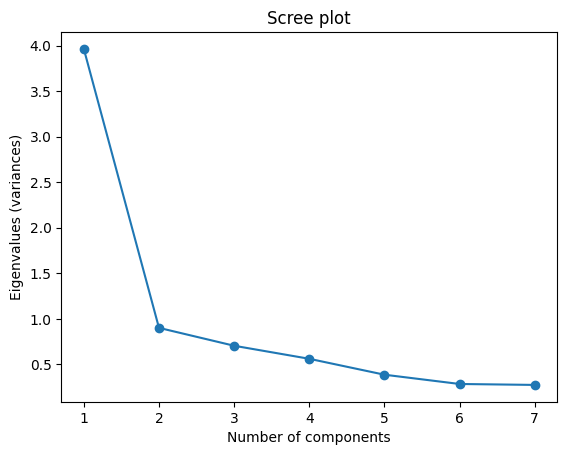

In [25]:
# по оси X: номер главной компоненты
# по оси Y: собственное значение для каждой компоненты

plt.plot(range(1, p + 1), pca_var, "o-");
plt.title("Scree plot");
plt.xlabel("Number of components");
plt.ylabel("Eigenvalues (variances)");

Понятие излома, конечно, не очень строгое, но здесь он явно в точке 2, то есть по-прежнему имеет смысл согласиться на одну главную компоненту.

Доля объясненной дисперсии каждой главной компонентой – отношение соответствующего собственного значения к сумме всех собственных значений, которая совпадает с числом главных компонент или исходных переменных:

In [26]:
print(pca_var / pca_var.sum())
print(pca_var / p)

[0.56041308 0.1273076  0.09953572 0.07928078 0.05457332 0.04017421
 0.03871529]
[0.56637493 0.12866193 0.10059461 0.08012419 0.05515389 0.04060159
 0.03912716]


Те же значения можно получить из атрибута `.explained_variance_ratio_`, и например, перевести доли в проценты:

In [27]:
pca_var_ratio = pca.explained_variance_ratio_
print((pca_var_ratio * 100).round(2))

[56.04 12.73  9.95  7.93  5.46  4.02  3.87]


Любым способом получаем, что первая главная компонента объясняет 56% дисперсии исходных данных. Маловато, хотя по предыдущим правилам все нормально. Можем все-таки выбрать две главные компоненты, поскольку вторую мы смогли содержательно проинтерпретировать – индекс аудиторной активности. В совокупности они будут объяснять примерно 70% общей дисперсии исходных показателей, что лучше.

Напоследок для удобства вычислим накопленные проценты объясненной дисперсии:

In [28]:
print(np.cumsum((pca_var_ratio * 100).round(2)))

[ 56.04  68.77  78.72  86.65  92.11  96.13 100.  ]


Если строго следовать последнему правилу, извлекать придется целых четыре главных компоненты (из 7, потому что исходных переменных 7). В данном случае это нецелесообразно, потому что компоненты, начиная с третьей по смыслу во многом будут дублировать исходные показатели (см. веса в `rotation` или  `A`).

### Работа в пространстве сниженной размерности

Добавим значения первых двух главных компонент в исходные данные:

In [29]:
pd.set_option('chained_assignment', None)

data["Index1"] = pca_res["PC1"]
data["Index2"] = pca_res["PC2"]
data.head()

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2,Index1,Index2
0,6,7,10,10,7,8.0,8.333333,1.195023,0.551075
1,4,8,10,9,1,8.2,6.666667,0.229391,-0.880323
2,9,10,10,10,3,7.2,7.000000,1.478203,-0.552319
3,4,7,9,10,10,8.2,9.666667,1.258709,1.377982
4,8,9,10,8,8,8.2,9.333333,1.745473,0.822709


Как установили, первая главная компонента – общий индекс успеваемости по курсу ТВиМС, второй – индекс аудиторной активности. Построим диаграмму рассеивания между этими индексами:

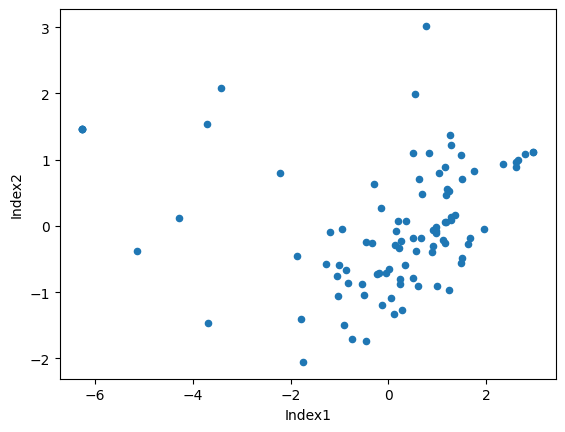

In [30]:
data.plot.scatter("Index1", "Index2");

Ожидать здесь облако с явным наклоном нет смысла, главные компоненты должны быть ортогональны, то есть нескоррелированы. Однако иногда расположение точек на плоскости могут натолкнуть на идеи о группах наблюдений, о кластерах. Здесь четких групп не наблюдается, поэтому можем просто посмотреть, какие студенты лидируют по значениям индексов:

In [31]:
# в топе – отличники по всем измерениям,
# компоненту можно считать индексом успеваемости

data.sort_values("Index1", ascending = False).head()

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2,Index1,Index2
27,10,10,10,10,10,10.0,9.333333,2.963433,1.111907
79,10,10,10,10,10,10.0,9.333333,2.963433,1.111907
91,9,10,10,10,10,9.6,9.666667,2.796247,1.089513
32,8,10,10,10,10,10.0,9.000000,2.643404,0.999802
34,9,10,10,10,10,9.4,8.333333,2.613340,0.969537


In [32]:
# вот тут уже спорно
# в топе активных студентов студенты с нулями за ДЗ,
# раз ДЗ неаудиторная активность – логично,
# но сюда закрались студенты и с нулевой активностью

data.sort_values("Index2", ascending = False).head(10)

,КР,ДЗ1,ДЗ2,ДЗ3,Семинары,Тесты1,Тесты2,Index1,Index2
66,8,9,0,10,10,7.0,7.666667,0.763849,3.018568
65,1,0,0,8,3,4.8,4.000000,-3.425100,2.081498
90,9,9,0,10,5,8.8,6.000000,0.551012,1.991899
94,2,6,0,0,0,3.4,6.333333,-3.717637,1.539314
58,0,0,0,0,0,0.0,0.000000,-6.259928,1.468175
46,0,0,0,0,0,0.0,0.000000,-6.259928,1.468175
36,0,0,0,0,0,0.0,0.000000,-6.259928,1.468175
69,0,0,0,0,0,0.0,0.000000,-6.259928,1.468175
3,4,7,9,10,10,8.2,9.666667,1.258709,1.377982
21,6,7,10,10,10,5.6,10.000000,1.272376,1.218177


In [ ]:
#

Мораль: если нули эквиваленты пропускам (а здесь это «мертвые души», которые есть в списке, но уже не учатся) их надо убрать, чтобы они не создавали проблем. Попробуйте это сделать и повторить МГК, результаты будут немного иными.